<a href="https://colab.research.google.com/github/naiomi2221/customer_churn_prediction/blob/main/IN503_NAIOMIZUPKO_WEEK10_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 1: Environment Setup**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [ ]:
#Set pandas display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

**PHASE 2: Data Acquisition and Exploration**

In [ ]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
filepath = path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv'
print("Path to dataset file: ", filepath)

df = pd.read_csv(filepath)

print("First 5 rows of the dataset:")
print(df.head())

print("\nShape of the dataset:")
print(df.shape)

print("\nDataFrame Info:")
df.info()

print("\nDescriptive statistics for numerical features:")
print(df.describe())

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset file:  /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year        

In [ ]:
print("\nMissing values before handling:")
print(df.isnull())

# Check for empty strings in TotalCharges
total_charges_missing = df[df['TotalCharges'] == ' '].shape[0]
print(f"\nNumber of empty strings in 'TotalCharges': {total_charges_missing}")

#Replace empty string with NaN and convert values to float
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan).astype(float)

#Re-check for missing values
print("\nMissing values after handling 'TotalCharges' type:")
print(df.isnull().sum())


Missing values before handling:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn
0          False   False          False    False       False   False         False          False            False           False         False             False        False        False            False     False             False          False           False         False  False
1          False   False          False    False       False   False         False          False            False           False         False             False        False        False            False     False             False          False           False         False  False
2          False   False          False    False       False   False         False          False            

In [ ]:
#Drop rows with missing values
df.dropna(inplace=True)

#Verify Cleanup
print("\nMissing values after dropping rows:")
print(df.isnull().sum())
print(f"New dataset shape: {df.shape}")



Missing values after dropping rows:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
New dataset shape: (7032, 21)


In [ ]:
print("\nChurn distribution:")
print(df['Churn'].value_counts())

#Calculate percentages
churn_percentages = df['Churn'].value_counts(normalize=True) * 100
print("\nChurn percentages:")
print(churn_percentages)



Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


**Visualization 1: Churn by Contract Type**

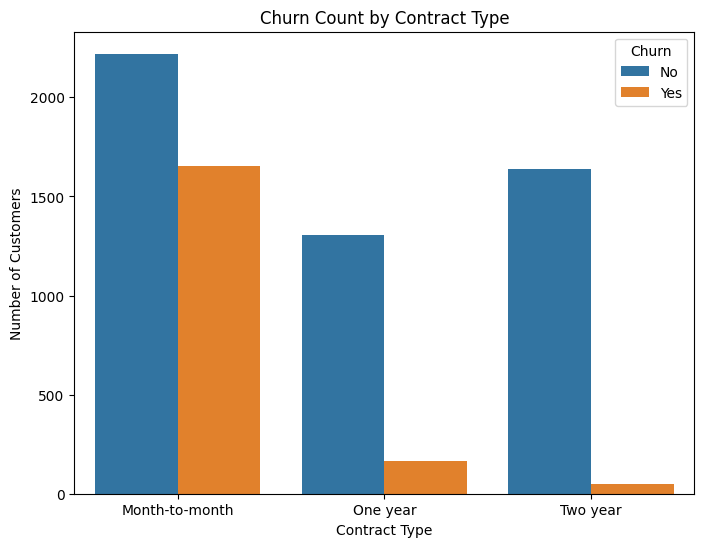

In [ ]:
#Create visualization
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

**Visualization 2: Churn by Internet Service**

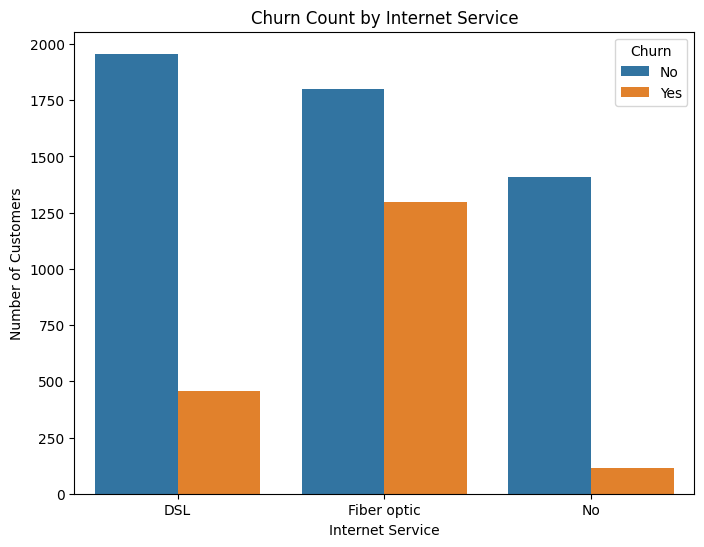

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn Count by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

**Visualization 3: Monthly Charges Distribution**

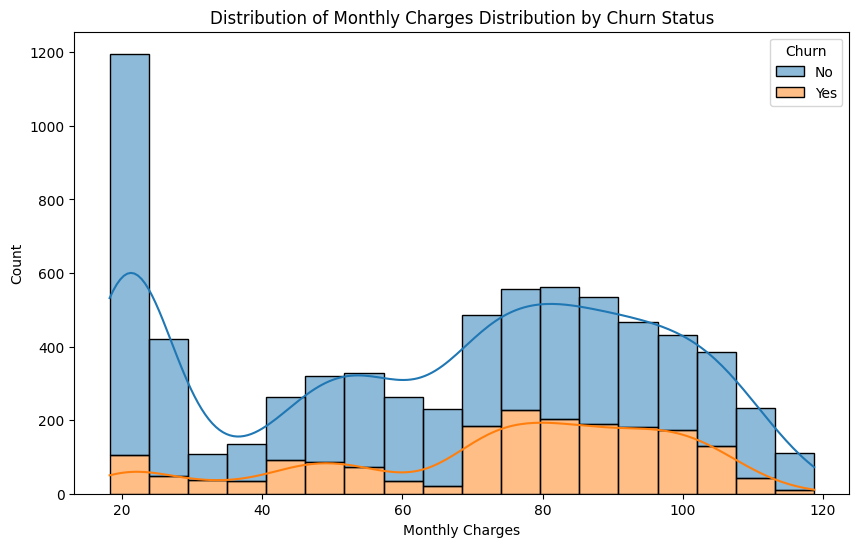

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', kde=True)
plt.title('Distribution of Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

**Visualization 4: Tenure Distribution**

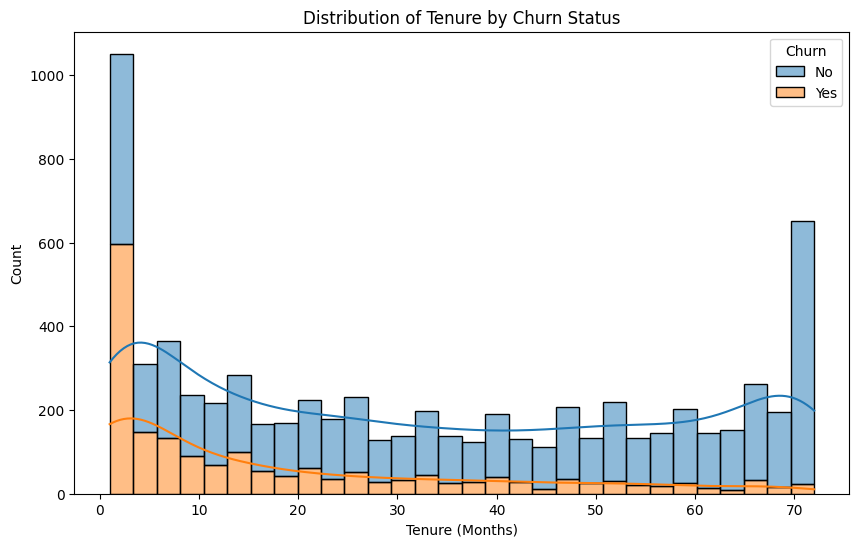

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', bins=30, hue='Churn', multiple='stack', kde=True)
plt.title('Distribution of Tenure by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

**Visualization 5: Correlation Heatmap**

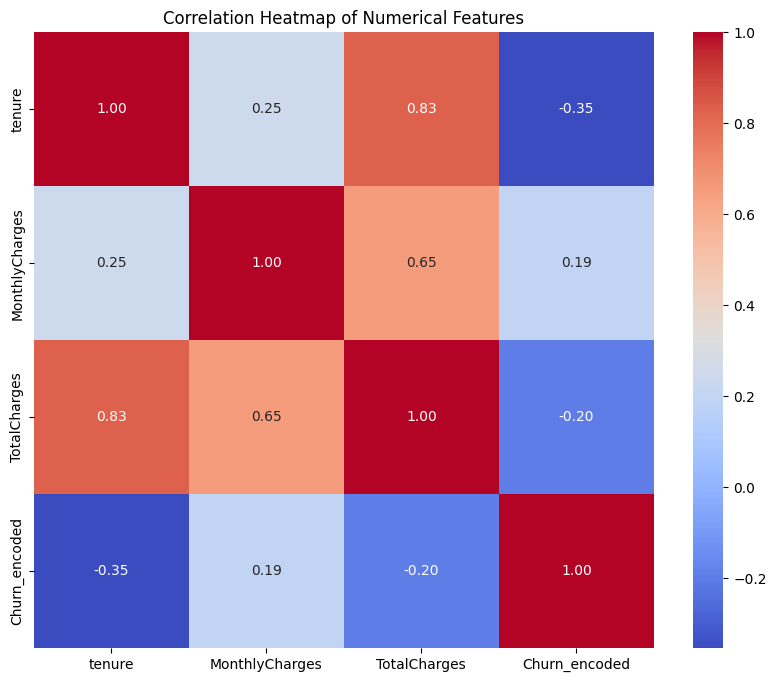

In [ ]:
df['Churn_encoded'] = df['Churn'].map({'Yes': 1, 'No': 0})
numerical_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_encoded']]

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#Clean up temporary column
df.drop('Churn_encoded', axis=1, inplace=True)

**PHASE 3: Data Preprocessing and Feature Engineering**

In [ ]:
df.drop('customerID', axis=1, inplace=True)

#Define features (x) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert target to numerical format
y = y.map({'Yes': 1, 'No': 0})

# Identify Column Types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

print(f"\nCategorical Columns: {list(categorical_cols)}")
print(f"\nNumerical Columns: {list(numerical_cols)}")

# Create transformers for preprocessing
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline with preprocessing and model



Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


**PHASE 4: Model Building and Training**

In [ ]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, \
                                                    random_state=42,
                                                    stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


Training set size: 5625 rows
Testing set size: 1407 rows


In [ ]:
# Create complete pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))

])
# TRain the Model
print("\nTraining the logistic regression model.....")
model_pipeline.fit(X_train, y_train)
print("Model training completed.")


Training the logistic regression model.....
Model training completed.


**PHASE 5: Model Evaluation and Interpretation**

In [ ]:
# Make predictions on test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])

print("\nModel Evaluation on Test Data:")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Model Evaluation on Test Data:
Accuracy: 0.8038

Confusion Matrix:
[[917 116]
 [160 214]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [ ]:
# Extract trained components
log_reg = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

# Get feature names after one-hot-encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(numerical_cols) + list(ohe_feature_names)

# Create coefficients DataFrame
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})

# Sort by absolute coefficient value
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)

print("\nTop 10 most impactful features on Churn:")
print(coefficients.head(10))


Top 10 most impactful features on Churn:
                        Feature  Coefficient  Abs_Coefficient
1                        tenure    -1.349386         1.349386
38            Contract_Two year    -0.785987         0.785987
3                  TotalCharges     0.640922         0.640922
15          InternetService_DSL    -0.614660         0.614660
36      Contract_Month-to-month     0.601468         0.601468
16  InternetService_Fiber optic     0.558548         0.558548
2                MonthlyCharges    -0.503458         0.503458
39          PaperlessBilling_No    -0.318278         0.318278
12             MultipleLines_No    -0.304254         0.304254
17           InternetService_No    -0.288752         0.288752


**PHASE 6: save the Model**

In [ ]:
#Save the complete pipeline
model_filename = 'customer_churn_model.pkl'
joblib.dump(model_pipeline, model_filename)
print(f"\nTrained model pipeline saved as '{model_filename}'")

# Load the saved model
model_pipeline = joblib.load('customer_churn_model.pkl')
print("Model pipeline loaded successfully.")

# Create example customer data
new_customer_data = {
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [1],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [75.75],
    'TotalCharges': [75.75]
}
# Convert to DataFrame and predict
new_customer_df = pd.DataFrame(new_customer_data)
prediction = model_pipeline.predict(new_customer_df)
churn_prediction = 'Yes' if prediction[0] == 1 else 'No'

print("\nNew customer data:")
print(new_customer_df)
print(f"\nPredicted Churn: {churn_prediction}")


Trained model pipeline saved as 'customer_churn_model.pkl'
Model pipeline loaded successfully.

New customer data:
  gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling     PaymentMethod  MonthlyCharges  TotalCharges
0   Male              0      No         No       1          Yes            No     Fiber optic             No           No               No          No          No              No  Month-to-month              Yes  Electronic check           75.75         75.75

Predicted Churn: Yes
